In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 777
np.random.seed(SEED)

In [3]:
from sklearn.model_selection import train_test_split

# cargo el dataset básico primero para separarlo en train y test
basic = pd.read_csv('../data/scaled/data_basic.csv')


# separación de características y objetivo
X_basic = basic.drop('Variable de Salida', axis=1)
y_basic = basic['Variable de Salida']

# separación en train y test
X_basic_train, X_basic_test, y_basic_train, y_basic_test = train_test_split(X_basic, y_basic, test_size=0.2, random_state = SEED, shuffle=True, stratify=y_basic)

# uno de nuevo y los meto ya en el 

basic = (pd.concat([X_basic_train, y_basic_train], axis=1), pd.concat([X_basic_test, y_basic_test], axis=1))


In [4]:
# cargar el resto de los datos en un diccionario de datasets, donde la clave es el tipo de trato y el valor una tupla (train, test)

datasets = {
    'basic': basic,
    'max_abs': (pd.read_csv('../data/scaled/data_trainmax_abs.csv'), pd.read_csv('../data/scaled/data_testmax_abs.csv')),
    'min_max': (pd.read_csv('../data/scaled/data_trainmin_max.csv'), pd.read_csv('../data/scaled/data_testmin_max.csv')),
    'robust': (pd.read_csv('../data/scaled/data_trainrobust.csv'), pd.read_csv('../data/scaled/data_testrobust.csv')),
    'standard': (pd.read_csv('../data/scaled/data_trainstandard.csv'), pd.read_csv('../data/scaled/data_teststandard.csv'))
}

In [17]:
# antes de nada divido ya en X e y los datasets del diccionario

for name, (train, test) in datasets.items():
    X_train = train.drop('Variable de Salida', axis=1)
    y_train = train['Variable de Salida']

    X_test = test.drop('Variable de Salida', axis=1)
    y_test = test['Variable de Salida']

    datasets[name] = (X_train, X_test, y_train, y_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# el primero método de selección de características a utilizar será el mítico
# random forest, por la simplicidad, no estoy entrenando el mejor model aún
# solo sacando características, esto lo voy a hacer sobre el dataset basic
# dado que para árboles no hay necesidad de escalar los datos

X_train, X_test, y_train, y_test = datasets['basic']

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

random_forest = RandomForestClassifier(max_depth=5,
                                       min_samples_leaf=20,
                                       class_weight='balanced',
                                       random_state=SEED,
                                       n_jobs=-1)

rfecv = RFECV(estimator=random_forest,
              cv=cv,
              scoring='f1_macro',
              n_jobs=-1)

rfecv.fit(X_train, y_train)

print(f'Numero optimo de características: {rfecv.n_features_}')
rfecv.support_





Numero optimo de características: 89


array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True, False,  True, False,
        True,  True, False, False, False, False, False, False, False,
       False,  True, False,  True])

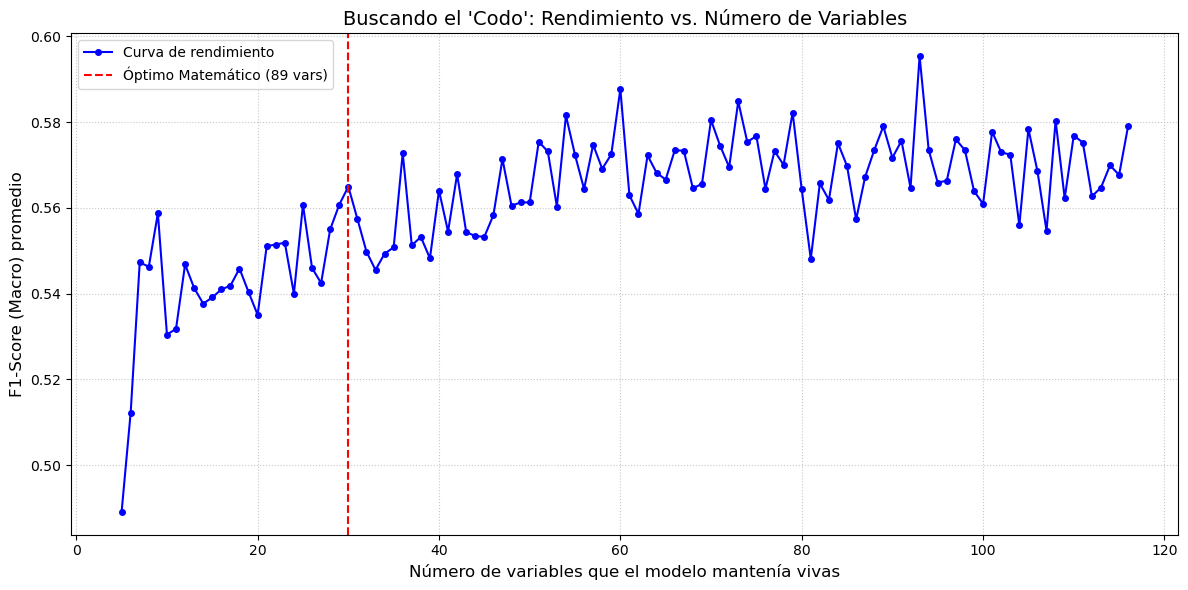

In [40]:
# tras probar un par de combinaciones, veo que esto no está funcionando muy bien,
# forzando un poco solo consigo que se quede con 89 variables como mínimo,
# esto se debe a la sensibilidad al f1-score, el gráfico se lo debemos a gemini,

resultados_cv = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(12, 6))
plt.title("Buscando el 'Codo': Rendimiento vs. Número de Variables", fontsize=14)
plt.xlabel("Número de variables que el modelo mantenía vivas", fontsize=12)
plt.ylabel("F1-Score (Macro) promedio", fontsize=12)

# Asumiendo que pusiste min_features_to_select=5 en tu RFECV
eje_x = range(5, len(resultados_cv) + 5) 

# Dibujamos la línea principal
plt.plot(eje_x, resultados_cv, marker='o', color='b', markersize=4, label='Curva de rendimiento')

# Marcamos el "óptimo" engañoso que te dio el modelo
plt.axvline(x=30, color='r', linestyle='--', 
            label=f'Óptimo Matemático ({rfecv.n_features_} vars)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
from sklearn.feature_selection import RFE
# con este gráfico podemos ver que a partir de las 9 variables el aumento en el
# f1 no es significativo

n_features1 = 25
n_features2 = 9

X_train, X_test, y_train, y_test = datasets['basic']

random_forest = RandomForestClassifier(max_depth=5,
                                       min_samples_leaf=20,
                                       class_weight='balanced',
                                       random_state=SEED,
                                       n_jobs=-1)

rfe_25 = RFE(estimator=random_forest,
              n_features_to_select=n_features1)

rfe_9 = RFE(estimator=random_forest,
              n_features_to_select=n_features2)


rfe_25.fit(X_train, y_train)
rfe_9.fit(X_train, y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...dom_state=777)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",9
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [51]:
# curiosidad: las 9 variables están todas en el modelo de 25
columnas_25 = X_train.columns[rfe_25.support_]
columnas_9 = X_train.columns[rfe_9.support_]


In [54]:
# ahora dos nuevos diccionarios con los datasets modificados

datasets_25 = {}
datasets_9 = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    datasets_25[name] = (X_train[columnas_25], X_test[columnas_25], y_train, y_test)
    datasets_9[name] = (X_train[columnas_9], X_test[columnas_9], y_train, y_test)


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ahora repetimos como en el notebook anterior, modelos clásicos, empezando
# por regresión logística

# creo un diccionario con los modelos logísticos
modelos_rl_25 = {}

for nombre, (X_train, X_test, y_train, y_test,) in datasets_25.items():
    print(nombre)
    rl = LogisticRegression(max_iter=10000, random_state=SEED, class_weight='balanced')

    rl.fit(X_train, y_train)

    modelos_rl[nombre] = rl

    predicciones = rl.predict(X_test)

    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





basic
[[107  56]
 [ 22  21]]
              precision    recall  f1-score   support

           0       0.83      0.66      0.73       163
           1       0.27      0.49      0.35        43

    accuracy                           0.62       206
   macro avg       0.55      0.57      0.54       206
weighted avg       0.71      0.62      0.65       206

max_abs
[[99 64]
 [21 22]]
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       163
           1       0.26      0.51      0.34        43

    accuracy                           0.59       206
   macro avg       0.54      0.56      0.52       206
weighted avg       0.71      0.59      0.62       206

min_max
[[99 64]
 [20 23]]
              precision    recall  f1-score   support

           0       0.83      0.61      0.70       163
           1       0.26      0.53      0.35        43

    accuracy                           0.59       206
   macro avg       0.55      0.57      0.53  

In [58]:
modelos_rl_9 = {}

for nombre, (X_train, X_test, y_train, y_test,) in datasets_25.items():
    print(nombre)
    rl = LogisticRegression(max_iter=10000, random_state=SEED, class_weight='balanced')

    rl.fit(X_train, y_train)

    modelos_rl[nombre] = rl

    predicciones = rl.predict(X_test)

    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





basic
[[107  56]
 [ 22  21]]
              precision    recall  f1-score   support

           0       0.83      0.66      0.73       163
           1       0.27      0.49      0.35        43

    accuracy                           0.62       206
   macro avg       0.55      0.57      0.54       206
weighted avg       0.71      0.62      0.65       206

max_abs
[[99 64]
 [21 22]]
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       163
           1       0.26      0.51      0.34        43

    accuracy                           0.59       206
   macro avg       0.54      0.56      0.52       206
weighted avg       0.71      0.59      0.62       206

min_max
[[99 64]
 [20 23]]
              precision    recall  f1-score   support

           0       0.83      0.61      0.70       163
           1       0.26      0.53      0.35        43

    accuracy                           0.59       206
   macro avg       0.55      0.57      0.53  

In [ ]:
# La mejora respecto del dataset tratado con PCA es prácticamente nula. Lo cual
# era de esperar puesto que ya ha quedado bastante claro que la naturaleza de 
# el dataset no es lineal.

In [65]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# ahora probaré con una svm

# parámetros a probar
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale','auto', 0.1, 0.01, 0.001]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
        'degree': [2, 3]
    }
]

modelos_svc_25 = {}

for nombre, (X_train, X_test, y_train, y_test) in datasets_25.items():
    svc = SVC(class_weight='balanced', max_iter=50000)
    
    clf = GridSearchCV(svc, param_grid, n_jobs=-1, cv=5, verbose=0, refit=True, scoring='f1_macro')
    clf.fit(X_train, y_train)

    # al poner refit = True, clf actúa directamente como mejor modelo
    modelos_svc_25[nombre] = clf

    predicciones = clf.predict(X_test)

    print(nombre)
    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

basic
[[103  60]
 [ 18  25]]
              precision    recall  f1-score   support

           0       0.85      0.63      0.73       163
           1       0.29      0.58      0.39        43

    accuracy                           0.62       206
   macro avg       0.57      0.61      0.56       206
weighted avg       0.73      0.62      0.66       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

max_abs
[[111  52]
 [ 20  23]]
              precision    recall  f1-score   support

           0       0.85      0.68      0.76       163
           1       0.31      0.53      0.39        43

    accuracy                           0.65       206
   macro avg       0.58      0.61      0.57       206
weighted avg       0.73      0.65      0.68       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

min_max
[[110  53]
 [ 22  21]]
              precision    recall  f1-score   support

           0       0.83      0.67      0.75       163
           1       0.28      0.49      0.36        43

    accuracy                           0.64       206
   macro avg       0.56      0.58      0.55       206
weighted avg       0.72      0.64      0.67       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

robust
[[116  47]
 [ 28  15]]
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       163
           1       0.24      0.35      0.29        43

    accuracy                           0.64       206
   macro avg       0.52      0.53      0.52       206
weighted avg       0.69      0.64      0.66       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

standard
[[100  63]
 [ 18  25]]
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       163
           1       0.28      0.58      0.38        43

    accuracy                           0.61       206
   macro avg       0.57      0.60      0.55       206
weighted avg       0.73      0.61      0.64       206



In [66]:
modelos_svc_9 = {}

for nombre, (X_train, X_test, y_train, y_test) in datasets_9.items():
    svc = SVC(class_weight='balanced', max_iter=50000)
    
    clf = GridSearchCV(svc, param_grid, n_jobs=-1, cv=5, verbose=0, refit=True, scoring='f1_macro')
    clf.fit(X_train, y_train)

    # al poner refit = True, clf actúa directamente como mejor modelo
    modelos_svc_9[nombre] = clf

    predicciones = clf.predict(X_test)

    print(nombre)
    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

basic
[[116  47]
 [ 25  18]]
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       163
           1       0.28      0.42      0.33        43

    accuracy                           0.65       206
   macro avg       0.55      0.57      0.55       206
weighted avg       0.71      0.65      0.67       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

max_abs
[[97 66]
 [21 22]]
              precision    recall  f1-score   support

           0       0.82      0.60      0.69       163
           1       0.25      0.51      0.34        43

    accuracy                           0.58       206
   macro avg       0.54      0.55      0.51       206
weighted avg       0.70      0.58      0.62       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

min_max
[[120  43]
 [ 25  18]]
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       163
           1       0.30      0.42      0.35        43

    accuracy                           0.67       206
   macro avg       0.56      0.58      0.56       206
weighted avg       0.72      0.67      0.69       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


robust
[[110  53]
 [ 21  22]]
              precision    recall  f1-score   support

           0       0.84      0.67      0.75       163
           1       0.29      0.51      0.37        43

    accuracy                           0.64       206
   macro avg       0.57      0.59      0.56       206
weighted avg       0.73      0.64      0.67       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


standard
[[93 70]
 [20 23]]
              precision    recall  f1-score   support

           0       0.82      0.57      0.67       163
           1       0.25      0.53      0.34        43

    accuracy                           0.56       206
   macro avg       0.54      0.55      0.51       206
weighted avg       0.70      0.56      0.60       206



In [76]:
# de nuevo, la mejora no ha sido demasiado grande, vamos ahora a probar con RandomForest

# en este caso nos sirve con probarlo para el dataset basic de 25 variables y 9

X_train_25, X_test_25, y_train_25, y_test_25 = datasets_25['basic']
X_train_9, X_test_9, y_train_9, y_test_9 = datasets_9['basic']
X_train, X_test, y_train, y_test = datasets['basic']

rf_modelo_25 = RandomForestClassifier(
    n_estimators=200,          # 200 árboles
    max_depth=10,              # Profundidad controlada para no sobreajustar
    min_samples_leaf=4,        # Exigimos evidencia para cada regla
    class_weight='balanced',   # Vital para contrarrestar el 80% NOK
    random_state=SEED,
    n_jobs=-1
)

rf_modelo_9 = RandomForestClassifier(
    n_estimators=200,          # 200 árboles
    max_depth=10,              # Profundidad controlada para no sobreajustar
    min_samples_leaf=15,        # Exigimos evidencia para cada regla
    class_weight='balanced',   # Vital para contrarrestar el 80% NOK
    random_state=SEED,
    n_jobs=-1
)

rf_modelo = RandomForestClassifier(
    n_estimators=200,          # 200 árboles
    max_depth=10,              # Profundidad controlada para no sobreajustar
    min_samples_leaf=15,        # Exigimos evidencia para cada regla
    class_weight='balanced',   # Vital para contrarrestar el 80% NOK
    random_state=SEED,
    n_jobs=-1
)

rf_modelo_25.fit(X_train_25, y_train_25)
rf_modelo_9.fit(X_train_9, y_train_9)
rf_modelo.fit(X_train, y_train)


predicciones_25 = rf_modelo_25.predict(X_test_25)
predicciones_9 = rf_modelo_9.predict(X_test_9)
predicciones = rf_modelo.predict(X_test)



print(confusion_matrix(y_test_25, predicciones_25))
print(classification_report(y_test_25, predicciones_25))

print(confusion_matrix(y_test_9, predicciones_9))
print(classification_report(y_test_9, predicciones_9))

print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))


[[145  18]
 [ 36   7]]
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       163
           1       0.28      0.16      0.21        43

    accuracy                           0.74       206
   macro avg       0.54      0.53      0.52       206
weighted avg       0.69      0.74      0.71       206

[[131  32]
 [ 31  12]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       163
           1       0.27      0.28      0.28        43

    accuracy                           0.69       206
   macro avg       0.54      0.54      0.54       206
weighted avg       0.70      0.69      0.70       206

[[132  31]
 [ 33  10]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       163
           1       0.24      0.23      0.24        43

    accuracy                           0.69       206
   macro avg       0.52      0.52      0.52       206
weigh

In [ ]:
# los resultados en este escenario tampoco han sido muy reconfortantes

In [89]:
import xgboost as xgb

# ahora probaré con xgboost

peso_positivo = 4

""" xgb_25 = xgb.XGBClassifier(
    scale_pos_weight=peso_positivo,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss'
) """

xgb_9 = xgb.XGBClassifier(
    scale_pos_weight=peso_positivo,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.01,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='aucpr'
)

""" xgb_ = xgb.XGBClassifier(
    scale_pos_weight=peso_positivo,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss'
) """

#xgb_25.fit(X_train_25, y_train_25)
xgb_9.fit(X_train_9, y_train_9)
#xgb_.fit(X_train, y_train)

#predicciones_25 = xgb_25.predict(X_test_25)
predicciones_9 = xgb_9.predict(X_test_9)
#predicciones = xgb_.predict(X_test)

""" print(confusion_matrix(y_test_25, predicciones_25))
print(classification_report(y_test_25, predicciones_25)) """

print(confusion_matrix(y_test_9, predicciones_9))
print(classification_report(y_test_9, predicciones_9))

""" print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))
 """

[[107  56]
 [ 21  22]]
              precision    recall  f1-score   support

           0       0.84      0.66      0.74       163
           1       0.28      0.51      0.36        43

    accuracy                           0.63       206
   macro avg       0.56      0.58      0.55       206
weighted avg       0.72      0.63      0.66       206



' print(confusion_matrix(y_test, predicciones))\nprint(classification_report(y_test, predicciones))\n '

In [104]:
from sklearn.model_selection import RandomizedSearchCV
# esta última baza tampoco ha dado unos resultado excelentes, voy a hacer un
# grid search para el dataset de 9 variables que es el que mejor resultados está
# arrojando

xgb_base = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric='aucpr',
    tree_method = 'hist'
)

param_grid = {
    'learning_rate': [0.001, 0.005, 0.01],
    'max_depth': [4,5,6],
    'n_estimators': [800,900, 1200],
    'min_child_weight': [9,10,12,15],
    'subsample': [0.8,1.0],
    'colsample_bytree': [0.4, 0.6,0.8],
    'scale_pos_weight': [4,5,6],
    'gamma': [0.2,0.3,0.4]
}

grid_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=80,        # número de configuraciones a probar
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

grid_xgb.fit(X_train, y_train)


print(f"Mejores hiperparámetros encontrados:\n{grid_xgb.best_params_}")

modelo_ganador = grid_xgb.best_estimator_

predicciones_ganador = modelo_ganador.predict(X_test)
print(confusion_matrix(y_test, predicciones_ganador))
print(classification_report(y_test, predicciones_ganador))


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores hiperparámetros encontrados:
{'subsample': 1.0, 'scale_pos_weight': 6, 'n_estimators': 800, 'min_child_weight': 9, 'max_depth': 5, 'learning_rate': 0.001, 'gamma': 0.4, 'colsample_bytree': 0.8}
[[ 59 104]
 [  9  34]]
              precision    recall  f1-score   support

           0       0.87      0.36      0.51       163
           1       0.25      0.79      0.38        43

    accuracy                           0.45       206
   macro avg       0.56      0.58      0.44       206
weighted avg       0.74      0.45      0.48       206



AttributeError: 'XGBClassifier' object has no attribute 'clasess_'

In [105]:
from sklearn.metrics import f1_score

probs = grid_xgb.best_estimator_.predict_proba(X_test)[:,1]

best_f1 = 0
best_t = 0

for t in np.linspace(0.05,0.6,200):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test,preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.5087939698492462 0.384180790960452
